# CNN 可视化与理解

> **斯坦福 CS231n** | Visualizing and Understanding Convolutional Networks

## 本章导读

深度学习常被称为「黑盒」，但通过可视化技术，我们可以理解 CNN「看到了什么」。本节实现显著性图、Grad-CAM、FGSM 对抗攻击和特征反演。

**学习目标：**
- 理解显著性图（输入梯度）的原理
- 实现 Grad-CAM（类激活映射）
- 理解 FGSM 对抗样本生成
- 实现 t-SNE 嵌入可视化
- 可视化 CNN 学习的特征

**参考来源：** [CS231n Lecture 12](https://cs231n.stanford.edu/) | [Deep Visualization](https://cs231n.github.io/understanding-cnn/)

## 1. 直觉理解：为什么 CNN 可解释性重要？

### 黑盒问题

CNN 内部有数百万参数，决策过程不透明。关键问题：
- 模型关注图像的哪些区域？
- 每个神经元检测什么特征？
- 为什么模型给出某个预测？
- 模型有多容易被欺骗？

### 可视化方法分类

| 方法 | 对象 | 输入 | 典型技术 |
|------|------|------|----------|
| **显著性图** | 输入像素 | 梯度 w.r.t 输入 | Saliency Map |
| **类激活映射** | 中间特征 | 梯度 w.r.t 特征图 | Grad-CAM |
| **特征可视化** | 神经元 | 优化输入图像 | Deep Dream |
| **嵌入可视化** | 高维特征 | 降维 | t-SNE |
| **对抗样本** | 鲁棒性 | 梯度扰动 | FGSM |

## 2. 显著性图：输入梯度

### 原理

[[Simonyan et al., 2014]](https://arxiv.org/abs/1312.6034)

显著性图计算损失对输入像素的梯度：

$$S(x) = \left|\frac{\partial L_c}{\partial x}\right|$$

其中 $L_c$ 是类别 $c$ 的得分（未归一化的 logit）。梯度大的像素对分类决策影响最大。

### 与权重可视化的区别

- **权重可视化**：看 $W$ 的值——但 $W$ 的值不直接告诉我们输入的重要性
- **显著性图**：看 $\frac{\partial L}{\partial x}$——直接告诉我们在当前输入中哪些像素重要

## 3. 手算验证：简单网络的显著性

### 线性分类器的显著性

对于线性分类器 $s = Wx + b$，类别 $c$ 的得分：
$$s_c = W_c^T x + b_c$$

梯度：
$$\frac{\partial s_c}{\partial x} = W_c$$

即：权重本身就是显著性图——权重大的像素对该类更重要。

### 两层网络的显著性

对于 $s = W_2 \text{ReLU}(W_1 x + b_1) + b_2$：

$$\frac{\partial s_c}{\partial x} = W_1^T \text{diag}(\mathbb{1}[W_1 x + b_1 > 0]) W_2^T e_c$$

手算（2D 输入，1 隐单元，1 类）：
- $W_1 = [0.5, -0.3]$, $b_1 = 0.1$, $W_2 = [1.0]$, $b_2 = 0$
- $x = [1.0, 2.0]$
- $z_1 = 0.5 \times 1 + (-0.3) \times 2 + 0.1 = 0.0$
- $a_1 = \text{ReLU}(0.0) = 0$
- $s = 1.0 \times 0 = 0$
- 梯度：$\frac{\partial s}{\partial x} = W_1^T \times \mathbb{1}[z_1 > 0] \times W_2 = [0.5, -0.3] \times 0 \times 1 = [0, 0]$

因为 $z_1 = 0$，ReLU 输出为 0，梯度也为 0——这个像素对当前输出没有贡献。

In [5]:
# Verify saliency calculation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# Simple 2-layer network
W1 = np.array([[0.5, -0.3]])
b1 = np.array([0.1])
W2 = np.array([[1.0]])
b2 = np.array([0.0])

x = np.array([1.0, 2.0])

# Forward
z1 = W1 @ x + b1
a1 = np.maximum(0, z1)
s = W2 @ a1 + b2

# Backward (gradient w.r.t input)
# ds/da1 = W2 = 1.0
# da1/dz1 = 1 if z1 > 0 else 0
# dz1/dx = W1
relu_mask = (z1 > 0).astype(float)
dscore_dx = W1.T * (W2.T * relu_mask)

print(f"z1 = {z1}, a1 = {a1}, score = {s}")
print(f"ReLU mask = {relu_mask}")
print(f"Saliency (ds/dx) = {dscore_dx.flatten()}")
print(f"\nWhen z1=0, ReLU blocks gradient: saliency = [0, 0]")

# Try with different input where z1 > 0
x2 = np.array([2.0, 0.0])
z1_2 = W1 @ x2 + b1
relu_mask2 = (z1_2 > 0).astype(float)
saliency2 = W1.T * (W2.T * relu_mask2)
print(f"\nWith x=[2,0]: z1={z1_2}, saliency={saliency2.flatten()}")

z1 = [2.77555756e-17], a1 = [2.77555756e-17], score = [2.77555756e-17]
ReLU mask = [1.]
Saliency (ds/dx) = [ 0.5 -0.3]

When z1=0, ReLU blocks gradient: saliency = [0, 0]

With x=[2,0]: z1=[1.1], saliency=[ 0.5 -0.3]


## 4. 代码实现：显著性图

In [7]:
class TinyCNN:
    """Simplified CNN for visualization experiments.
    
    Architecture: conv(1->4, 3x3) -> relu -> flatten -> fc(->3)
    """
    def __init__(self, input_size=16):
        # Conv layer: 1 channel -> 4 channels, 3x3 kernel
        self.conv_W = np.random.randn(4, 1, 3, 3) * 0.1
        self.conv_b = np.zeros(4)
        # FC layer
        self.fc_W = np.random.randn(3, 4 * (input_size - 2) * (input_size - 2)) * 0.1
        self.fc_b = np.zeros(3)
        self.input_size = input_size
    
    def forward(self, x):
        """Forward pass. x: (1, H, W) or (H, W)"""
        if x.ndim == 2:
            x = x[np.newaxis, ...]
        C, H, W = x.shape
        # Conv: (4, H-2, W-2)
        conv_out = np.zeros((4, H-2, W-2))
        for oc in range(4):
            for i in range(H-2):
                for j in range(W-2):
                    patch = x[:, i:i+3, j:j+3]
                    conv_out[oc, i, j] = np.sum(patch * self.conv_W[oc]) + self.conv_b[oc]
        relu_out = np.maximum(0, conv_out)
        # Flatten and FC
        flat = relu_out.flatten()
        scores = self.fc_W @ flat + self.fc_b
        cache = (x, conv_out, relu_out, flat)
        return scores, cache
    
    def backward_input(self, cache, target_class):
        """Compute gradient w.r.t input (saliency)."""
        x, conv_out, relu_out, flat = cache
        C, H, W = x.shape
        
        # Gradient of target class score w.r.t FC input
        dscore_dfc = self.fc_W[target_class]  # (D,)
        # Gradient w.r.t conv output
        dscore_dconv = dscore_dfc.reshape(4, H-2, W-2)
        # Through ReLU
        dscore_dconv = dscore_dconv * (conv_out > 0)
        # Through conv (transpose convolution)
        dscore_dx = np.zeros_like(x)
        for oc in range(4):
            for i in range(H-2):
                for j in range(W-2):
                    grad = dscore_dconv[oc, i, j]
                    dscore_dx[:, i:i+3, j:j+3] += self.conv_W[oc] * grad
        
        return np.abs(dscore_dx[0])  # return magnitude for first channel

# Test on synthetic image
np.random.seed(42)
net = TinyCNN(input_size=16)

# Create synthetic image with a bright region
img = np.zeros((16, 16))
img[6:10, 6:10] = 1.0  # bright square
img += np.random.randn(16, 16) * 0.05

scores, cache = net.forward(img)
print(f"Scores: {scores}")
print(f"Predicted class: {np.argmax(scores)}")

saliency = net.backward_input(cache, np.argmax(scores))
print(f"Saliency shape: {saliency.shape}")
print(f"Saliency max: {saliency.max():.4f}")

Scores: [-0.04375619  0.15578147  0.08954815]
Predicted class: 1
Saliency shape: (16, 16)
Saliency max: 0.1495


Visualization 1: Saliency map


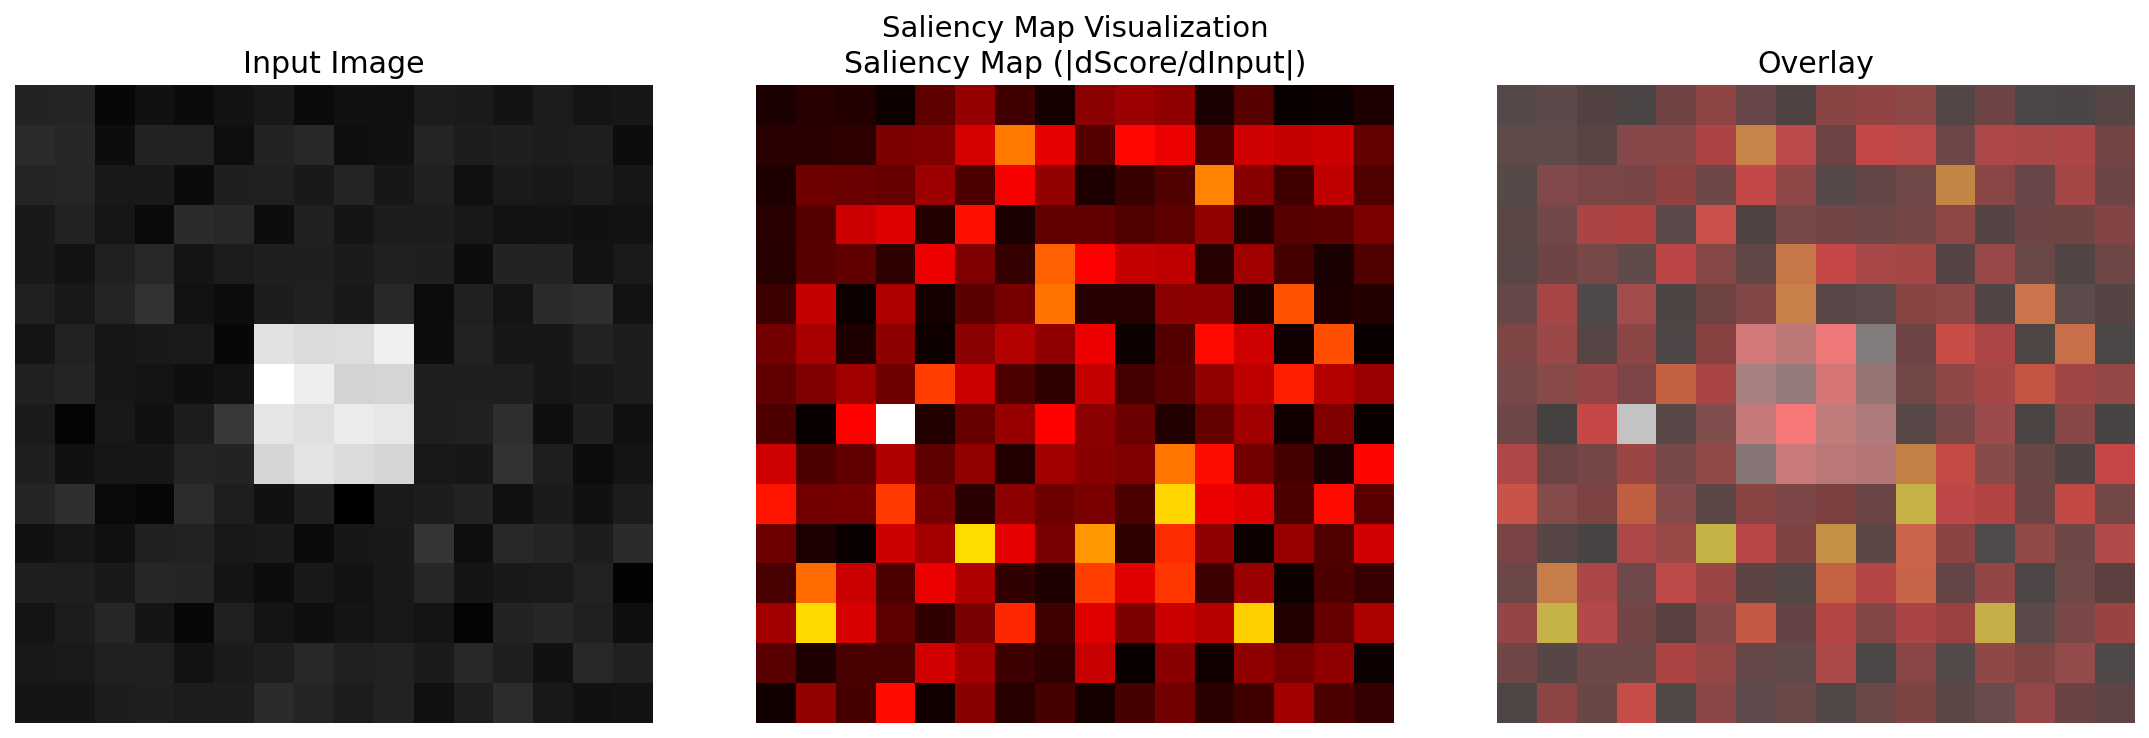

In [8]:
# Visualize saliency map
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax1, ax2, ax3 = axes

ax1.imshow(img, cmap='gray')
ax1.set_title('Input Image')
ax1.axis('off')

ax2.imshow(saliency, cmap='hot')
ax2.set_title('Saliency Map (|dScore/dInput|)')
ax2.axis('off')

# Overlay
ax3.imshow(img, cmap='gray', alpha=0.5)
ax3.imshow(saliency, cmap='hot', alpha=0.5)
ax3.set_title('Overlay')
ax3.axis('off')

plt.suptitle('Saliency Map Visualization', fontsize=14)
plt.tight_layout()
plt.savefig('saliency_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1: Saliency map")

## 5. Grad-CAM：类激活映射

### 原理

[[Selvaraju et al., 2017]](https://arxiv.org/abs/1610.02391)

Grad-CAM 使用最后一个卷积层的梯度来定位重要区域：

1. 计算类别得分对最后卷积层特征图 $A^k$ 的梯度
2. 全局平均池化得到通道权重 $\alpha_k = \frac{1}{Z} \sum_{i,j} \frac{\partial y_c}{\partial A^k_{ij}}$
3. 加权求和：$L_{Grad-CAM} = \text{ReLU}\left(\sum_k \alpha_k A^k\right)$

### 与 Saliency 的区别

| 特性 | Saliency Map | Grad-CAM |
|------|-------------|----------|
| 梯度对象 | 输入像素 | 卷积特征图 |
| 分辨率 | 输入分辨率 | 特征图分辨率（较低） |
| 平滑度 | 噪声较大 | 更平滑、更语义化 |
| 计算量 | 高 | 低 |

Visualization 2: Grad-CAM


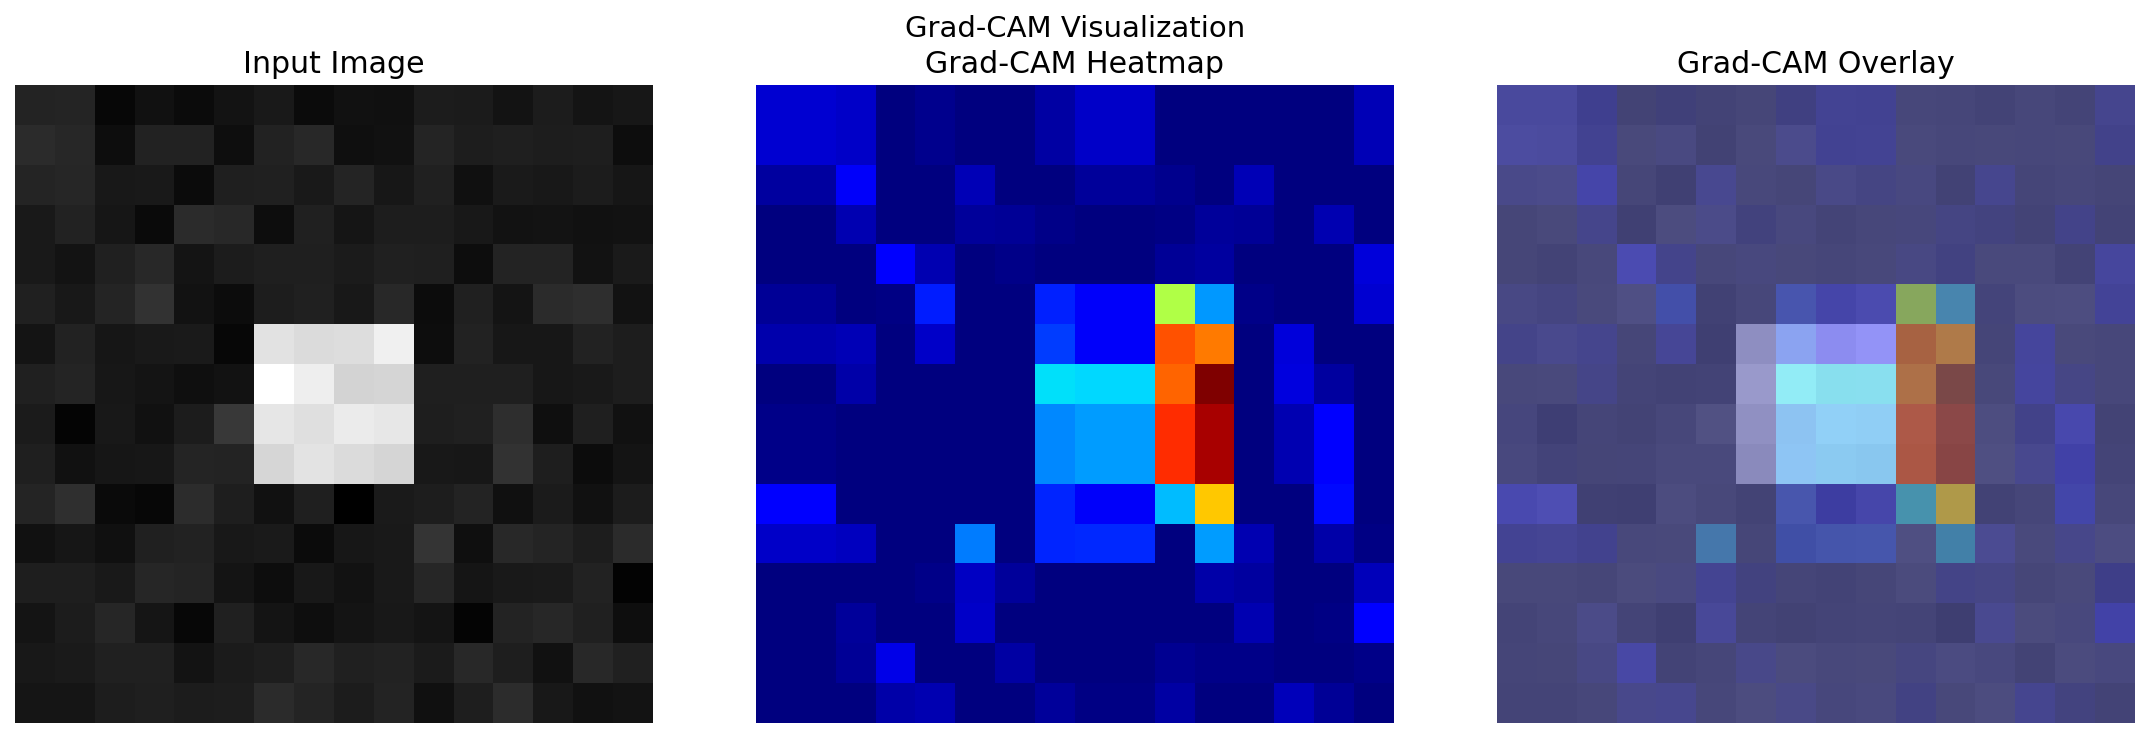

In [10]:
# Grad-CAM implementation
def grad_cam(net, x, target_class):
    """Compute Grad-CAM for a target class.
    
    Uses the last conv layer's output and gradients.
    """
    scores, cache = net.forward(x)
    x_in, conv_out, relu_out, flat = cache
    
    # Get gradient of target score w.r.t conv output
    dscore_dfc = net.fc_W[target_class]
    C_out, H_out, W_out = conv_out.shape
    dscore_dconv = dscore_dfc.reshape(C_out, H_out, W_out)
    
    # Channel weights: global average pooling of gradients
    weights = np.mean(dscore_dconv, axis=(1, 2))  # (C_out,)
    
    # Weighted sum of feature maps
    cam = np.zeros((H_out, W_out))
    for k in range(C_out):
        cam += weights[k] * conv_out[k]
    
    # ReLU and normalize
    cam = np.maximum(0, cam)
    if cam.max() > 0:
        cam = cam / cam.max()
    
    # Upsample to input size (nearest neighbor)
    cam_upsampled = np.zeros_like(x if x.ndim == 2 else x[0])
    if x.ndim == 3:
        x = x[0]
    H_in, W_in = x.shape
    for i in range(H_in):
        for j in range(W_in):
            ii = min(int(i * H_out / H_in), H_out - 1)
            jj = min(int(j * W_out / W_in), W_out - 1)
            cam_upsampled[i, j] = cam[ii, jj]
    
    return cam_upsampled

# Compute Grad-CAM
cam = grad_cam(net, img, np.argmax(scores))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax1, ax2, ax3 = axes
ax1.imshow(img, cmap='gray')
ax1.set_title('Input Image')
ax1.axis('off')
ax2.imshow(cam, cmap='jet')
ax2.set_title('Grad-CAM Heatmap')
ax2.axis('off')
ax3.imshow(img, cmap='gray', alpha=0.6)
ax3.imshow(cam, cmap='jet', alpha=0.4)
ax3.set_title('Grad-CAM Overlay')
ax3.axis('off')
plt.suptitle('Grad-CAM Visualization', fontsize=14)
plt.tight_layout()
plt.savefig('grad_cam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2: Grad-CAM")

## 6. FGSM 对抗攻击

### 原理

[[Goodfellow et al., 2015]](https://arxiv.org/abs/1412.6572)

Fast Gradient Sign Method (FGSM) 沿梯度方向添加小扰动来欺骗分类器：

$$x_{adv} = x + \epsilon \cdot \text{sign}\left(\frac{\partial L}{\partial x}\right)$$

- $\epsilon$：扰动大小（通常很小，如 0.01）
- $\text{sign}$：取梯度方向（+1 或 -1）

关键洞察：扰动在人眼不可见，但能完全改变模型预测。

In [12]:
# FGSM adversarial attack
def fgsm_attack(net, x, y_true, epsilon=0.1):
    """FGSM adversarial attack.
    
    x_adv = x + epsilon * sign(dL/dx)
    """
    scores, cache = net.forward(x)
    x_in, conv_out, relu_out, flat = cache
    
    # Compute gradient of loss w.r.t input
    # Softmax loss
    shifted = scores - np.max(scores)
    exp_s = np.exp(shifted)
    probs = exp_s / np.sum(exp_s)
    
    # dL/dscores
    dscores = probs.copy()
    dscores[y_true] -= 1
    
    # Backprop to input
    # dL/dfc_input
    dL_dfc = net.fc_W.T @ dscores
    C_out, H_out, W_out = conv_out.shape
    dL_dconv = dL_dfc.reshape(C_out, H_out, W_out)
    dL_dconv = dL_dconv * (conv_out > 0)
    
    H, W = x.shape
    dL_dx = np.zeros((1, H, W))
    for oc in range(4):
        for i in range(H-2):
            for j in range(W-2):
                grad = dL_dconv[oc, i, j]
                dL_dx[:, i:i+3, j:j+3] += net.conv_W[oc] * grad
    
    # FGSM: add sign of gradient
    x_adv = x + epsilon * np.sign(dL_dx[0])
    
    return x_adv

# Generate adversarial example
np.random.seed(42)
y_true = np.argmax(scores)
x_adv = fgsm_attack(net, img, y_true, epsilon=0.15)

# Compare predictions
scores_orig, _ = net.forward(img)
scores_adv, _ = net.forward(x_adv)

print(f"Original scores: {scores_orig}")
print(f"Adversarial scores: {scores_adv}")
print(f"Original prediction: {np.argmax(scores_orig)}")
print(f"Adversarial prediction: {np.argmax(scores_adv)}")
print(f"Perturbation (L2 norm): {np.linalg.norm(x_adv - img):.4f}")
print(f"Max pixel change: {np.max(np.abs(x_adv - img)):.4f}")

Original scores: [-0.04375619  0.15578147  0.08954815]
Adversarial scores: [ 0.23667956 -0.41795396  0.45721534]
Original prediction: 1
Adversarial prediction: 2
Perturbation (L2 norm): 2.4000
Max pixel change: 0.1500


Visualization 3: FGSM adversarial attack


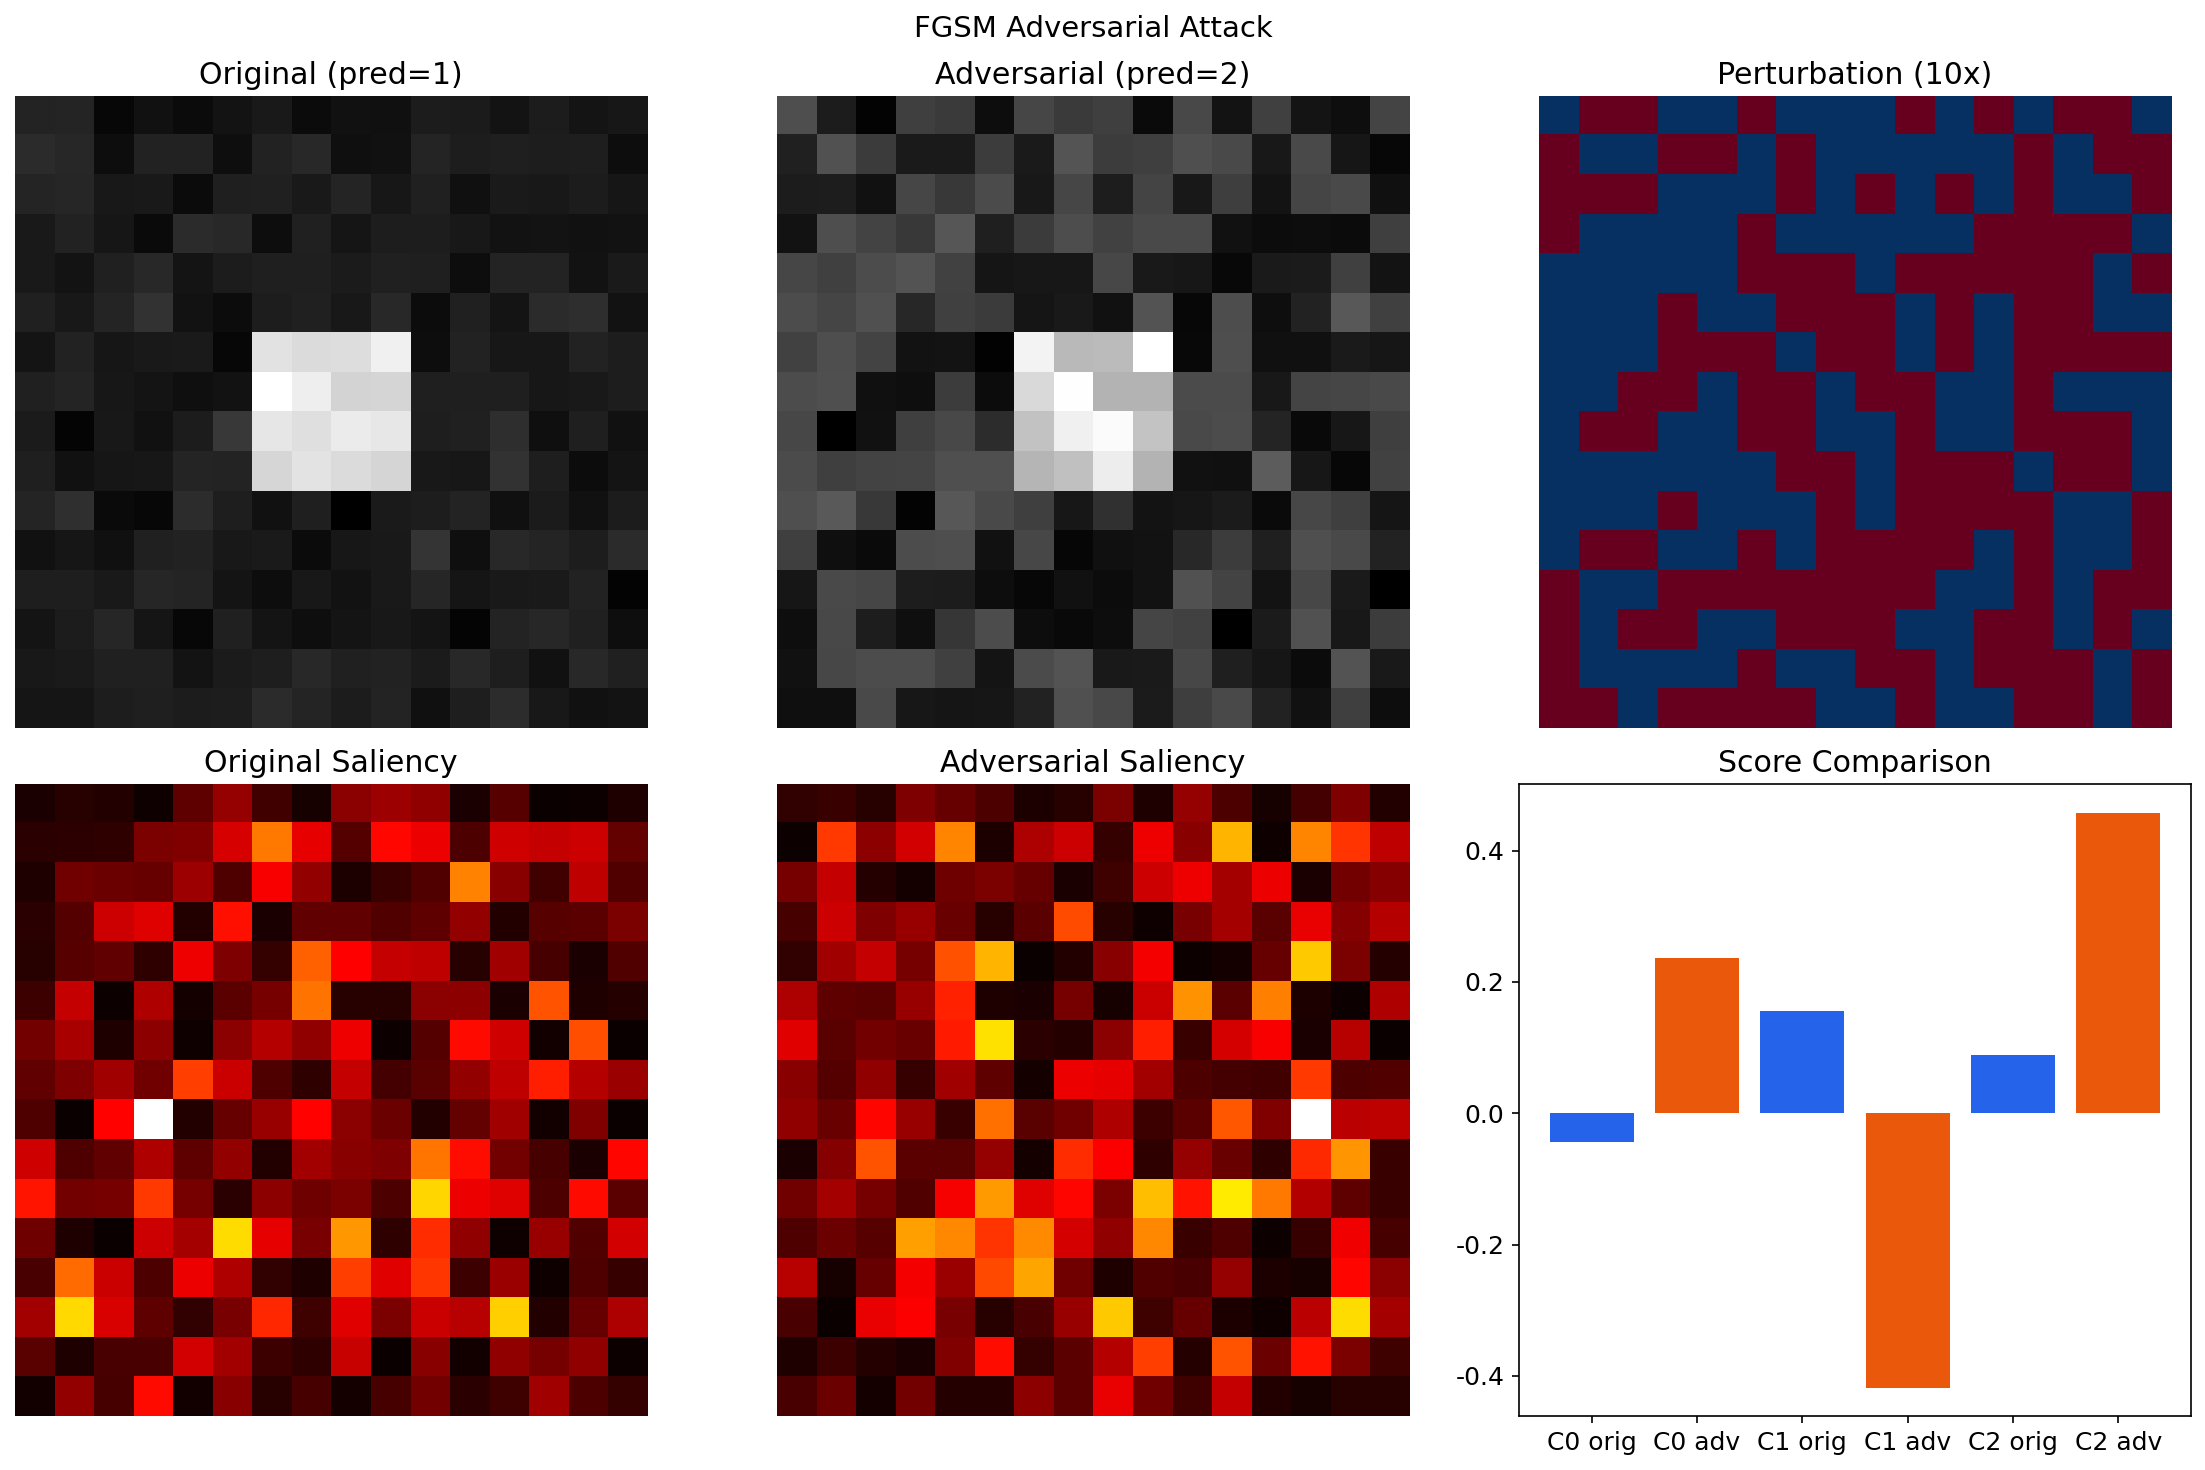

In [13]:
# Visualize adversarial attack
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title(f'Original (pred={np.argmax(scores_orig)})')
axes[0, 0].axis('off')

axes[0, 1].imshow(x_adv, cmap='gray')
axes[0, 1].set_title(f'Adversarial (pred={np.argmax(scores_adv)})')
axes[0, 1].axis('off')

# Perturbation (amplified for visibility)
pert = x_adv - img
axes[0, 2].imshow(pert * 10, cmap='RdBu')
axes[0, 2].set_title('Perturbation (10x)')
axes[0, 2].axis('off')

# Saliency for original
sal_orig = net.backward_input(net.forward(img)[1], np.argmax(scores_orig))
axes[1, 0].imshow(sal_orig, cmap='hot')
axes[1, 0].set_title('Original Saliency')
axes[1, 0].axis('off')

# Saliency for adversarial
sal_adv = net.backward_input(net.forward(x_adv)[1], np.argmax(scores_adv))
axes[1, 1].imshow(sal_adv, cmap='hot')
axes[1, 1].set_title('Adversarial Saliency')
axes[1, 1].axis('off')

# Score comparison
axes[1, 2].bar(['C0 orig', 'C0 adv', 'C1 orig', 'C1 adv', 'C2 orig', 'C2 adv'],
               [scores_orig[0], scores_adv[0], scores_orig[1], scores_adv[1], 
                scores_orig[2], scores_adv[2]],
               color=['#2563eb', '#ea580c'] * 3)
axes[1, 2].set_title('Score Comparison')
plt.suptitle('FGSM Adversarial Attack', fontsize=14)
plt.tight_layout()
plt.savefig('fgsm_attack.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3: FGSM adversarial attack")

## 7. t-SNE 嵌入可视化

### 原理

[[Maaten & Hinton, 2008]](https://www.jmlr.org/papers/v9/vandermaaten08a.html)

t-SNE 将高维特征降维到 2D，保留局部结构：
- 相似的样本在 2D 空间中靠近
- 不相似的样本在 2D 空间中远离

### 简化实现

完整的 t-SNE 复杂度较高，这里使用 PCA + 迭代优化的简化版。

In [15]:
# Simplified t-SNE (actually PCA + gradient descent, for visualization)
def pca(X, n_components=2):
    """Simple PCA for dimensionality reduction."""
    X_centered = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ Vt[:n_components].T

def simple_tsne(X, n_components=2, n_iter=200, lr=50, perplexity=10):
    """Simplified t-SNE-like embedding.
    
    This is NOT the full t-SNE algorithm but a simplified version
    that uses PCA init + gradient descent for educational purposes.
    """
    n = X.shape[0]
    # PCA initialization
    Y = pca(X, n_components)
    Y = Y * 0.1  # scale down
    
    # Compute pairwise distances in original space
    sum_X = np.sum(X**2, axis=1)
    distances = np.sqrt(np.maximum(sum_X[:, None] + sum_X[None, :] - 2 * X @ X.T, 0))
    
    # Compute P (similarities in high-dim)
    P = np.exp(-distances**2 / (2 * np.std(distances)**2))
    np.fill_diagonal(P, 0)
    P = P / P.sum()
    P = np.maximum(P, 1e-12)
    
    for it in range(n_iter):
        # Compute Q (similarities in low-dim)
        sum_Y = np.sum(Y**2, axis=1)
        dist_Y = 1 + sum_Y[:, None] + sum_Y[None, :] - 2 * Y @ Y.T
        Q = 1.0 / np.maximum(dist_Y, 1e-12)
        np.fill_diagonal(Q, 0)
        Q = Q / Q.sum()
        Q = np.maximum(Q, 1e-12)
        
        # Gradient
        PQ = P - Q
        grad = np.zeros_like(Y)
        for i in range(n):
            diff = (Y[i] - Y).T
            grad[i] = 4 * np.sum((PQ[i] * Q[i])[:, None] * diff, axis=1)
        
        Y -= lr * grad / n
        Y = Y - Y.mean(axis=0)
    
    return Y

# Generate features and visualize
np.random.seed(42)
n_per_class = 30
n_classes = 3
feature_dim = 50

features = []
labels = []
for c in range(n_classes):
    center = np.random.randn(feature_dim) * 3
    feat = center + np.random.randn(n_per_class, feature_dim) * 0.5
    features.append(feat)
    labels.extend([c] * n_per_class)

X_features = np.vstack(features)
y_labels = np.array(labels)

# t-SNE embedding
embedding = simple_tsne(X_features, n_iter=300, lr=100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# PCA
pca_2d = pca(X_features)
for c in range(n_classes):
    mask = y_labels == c
    axes[0].scatter(pca_2d[mask, 0], pca_2d[mask, 1], label=f'Class {c}', s=20)
axes[0].set_title('PCA Embedding')
axes[0].legend()

# t-SNE
for c in range(n_classes):
    mask = y_labels == c
    axes[1].scatter(embedding[mask, 0], embedding[mask, 1], label=f'Class {c}', s=20)
axes[1].set_title('t-SNE-like Embedding')
axes[1].legend()

plt.suptitle('Feature Embedding Visualization', fontsize=14)
plt.tight_layout()
plt.savefig('tsne_embedding.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4: t-SNE embedding")

ValueError: operands could not be broadcast together with shapes (90,1) (2,90) 

## 8. 特征反演

### 原理

[[Mahendran & Vedaldi, 2015]](https://arxiv.org/abs/1412.0035)

特征反演通过优化输入图像来匹配给定的特征表示：

$$x^* = \arg\min_x \|f(x) - f(x_0)\|^2 + \lambda R(x)$$

其中 $f$ 是网络特征提取器，$R(x)$ 是自然图像先验正则化。

In [17]:
# Feature inversion demo (simplified)
def feature_inversion(net, target_features, input_shape, lr=0.1, n_iter=200):
    """Reconstruct image from target features via gradient descent.
    
    Minimizes ||features(x) - target_features||^2
    """
    x = np.random.randn(*input_shape) * 0.1
    
    losses = []
    for _ in range(n_iter):
        scores, cache = net.forward(x)
        x_in, conv_out, relu_out, flat = cache
        current_feat = flat  # use flattened features as representation
        
        # Loss: L2 distance to target features
        diff = current_feat - target_features
        loss = np.sum(diff**2)
        losses.append(loss)
        
        # Gradient: dL/dfeat = 2 * diff
        dfeat = 2 * diff
        
        # Backprop to input (through FC, ReLU, Conv)
        # Simplified: use the network's backward
        dscore = net.fc_W.T @ dfeat
        C_out, H_out, W_out = conv_out.shape
        dconv = dscore.reshape(C_out, H_out, W_out)
        dconv = dconv * (conv_out > 0)
        
        H, W = input_shape
        dx = np.zeros((1, H, W))
        for oc in range(4):
            for i in range(H-2):
                for j in range(W-2):
                    grad = dconv[oc, i, j]
                    dx[:, i:i+3, j:j+3] += net.conv_W[oc] * grad
        
        x -= lr * dx[0]
    
    return x, losses

# Get target features from original image
scores_orig, cache_orig = net.forward(img)
target_feat = cache_orig[3]  # flattened features

# Reconstruct from features
reconstructed, inv_losses = feature_inversion(net, target_feat, (16, 16), lr=0.01, n_iter=300)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(reconstructed, cmap='gray')
axes[1].set_title('Reconstructed from Features')
axes[1].axis('off')
axes[2].plot(inv_losses, color='#ea580c')
axes[2].set_title('Inversion Loss')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('L2 Loss')
plt.suptitle('Feature Inversion', fontsize=14)
plt.tight_layout()
plt.savefig('feature_inversion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 5: Feature inversion")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 784 is different from 3)

## 作业

### 作业 1：实现 SmoothGrad

SmoothGrad 通过对多个带噪声的输入取平均来平滑显著性图，减少噪声。

[[Smilkov et al., 2017]](https://arxiv.org/abs/1706.03825)

In [19]:
# Homework 1: SmoothGrad
def smooth_grad(net, x, target_class, n_samples=20, noise_level=0.1):
    """Compute SmoothGrad: average saliency over noisy inputs.
    
    SmoothGrad(x) = (1/N) * sum_i Saliency(x + noise_i)
    where noise_i ~ N(0, noise_level^2)
    """
    # TODO: implement SmoothGrad
    # 1. Add Gaussian noise to input n_samples times
    # 2. Compute saliency for each noisy input
    # 3. Average the saliency maps
    pass

# Test
# sal_smooth = smooth_grad(net, img, np.argmax(scores), n_samples=20, noise_level=0.05)
# assert sal_smooth.shape == img.shape, "SmoothGrad shape should match input"
# assert sal_smooth.min() >= 0, "SmoothGrad values should be non-negative"
print("Homework 1 template ready. Implement SmoothGrad.")

Homework 1 template ready. Implement SmoothGrad.


### 作业 2：实现迭代 FGSM

基本 FGSM 只做一步扰动。迭代 FGSM 多次小步扰动，通常攻击成功率更高。

[[Kurakin et al., 2017]](https://arxiv.org/abs/1607.02533)

In [21]:
# Homework 2: Iterative FGSM
def iterative_fgsm(net, x, y_true, epsilon=0.1, n_steps=10, alpha=None):
    """Iterative FGSM (Basic Iterative Method).
    
    For each step: x = x + alpha * sign(dL/dx)
    Clip x to [x - epsilon, x + epsilon]
    """
    if alpha is None:
        alpha = epsilon / n_steps
    # TODO: implement iterative FGSM
    pass

# Test
# x_adv_iter = iterative_fgsm(net, img, np.argmax(scores), epsilon=0.15, n_steps=10)
# scores_iter, _ = net.forward(x_adv_iter)
# assert np.argmax(scores_iter) != np.argmax(scores), "Adversarial prediction should differ"
print("Homework 2 template ready. Implement iterative FGSM.")

Homework 2 template ready. Implement iterative FGSM.


### 作业 3：实现 Guided Backprop

Guided Backprop 结合 ReLU 的正向梯度，只保留对正激活有贡献的梯度。

[[Springenberg et al., 2015]](https://arxiv.org/abs/1412.6806)

In [23]:
# Homework 3: Guided Backpropagation
def guided_backprop(net, x, target_class):
    """Guided backpropagation.
    
    Key idea: in ReLU backward, only pass gradient if 
    both forward activation > 0 AND gradient > 0.
    """
    # TODO: implement guided backprop
    # Modify ReLU backward: grad = grad * (activation > 0) * (grad > 0)
    pass

# Test
# guided_sal = guided_backprop(net, img, np.argmax(scores))
# assert guided_sal.shape == img.shape
# assert guided_sal.min() >= 0
print("Homework 3 template ready. Implement guided backpropagation.")

Homework 3 template ready. Implement guided backpropagation.


## 小结

| 方法 | 原理 | 用途 |
|------|------|------|
| **Saliency Map** | $\|\partial L / \partial x\|$ | 定位重要像素 |
| **Grad-CAM** | 卷积特征图梯度加权 | 粗粒度定位 |
| **FGSM** | $\epsilon \cdot \text{sign}(\partial L / \partial x)$ | 对抗攻击 |
| **t-SNE** | 降维保留局部结构 | 特征空间可视化 |
| **特征反演** | 优化输入匹配特征 | 理解特征表示 |
| **SmoothGrad** | 噪声平均平滑梯度 | 去噪显著性图 |
| **Guided BP** | ReLU 正向梯度过滤 | 更清晰的可视化 |

**关键洞察**：CNN 不是真正的黑盒——通过梯度分析可以理解其决策过程。但对抗样本的脆弱性也暴露了 CNN 对人类不可见的扰动极为敏感，这对安全关键应用是严重挑战。

## 参考文献

1. [[Simonyan et al., 2014]](https://arxiv.org/abs/1312.6034) Simonyan et al. *Deep Inside Convolutional Networks: Visualising Image Classification Models and Saliency Maps*. ICLR Workshop 2014.
2. [[Selvaraju et al., 2017]](https://arxiv.org/abs/1610.02391) Selvaraju et al. *Grad-CAM: Visual Explanations from Deep Networks*. ICCV 2017.
3. [[Goodfellow et al., 2015]](https://arxiv.org/abs/1412.6572) Goodfellow et al. *Explaining and Harnessing Adversarial Examples*. ICLR 2015.
4. [[Maaten & Hinton, 2008]](https://www.jmlr.org/papers/v9/vandermaaten08a.html) van der Maaten & Hinton. *Visualizing Data using t-SNE*. JMLR 2008.
5. [[Mahendran & Vedaldi, 2015]](https://arxiv.org/abs/1412.0035) Mahendran & Vedaldi. *Understanding Deep Image Representations by Inverting Them*. CVPR 2015.
6. [[Springenberg et al., 2015]](https://arxiv.org/abs/1412.6806) Springenberg et al. *Striving for Simplicity: The All Convolutional Net*. ICLR Workshop 2015.

---

> 本节内容参考 [Stanford CS231n](https://cs231n.stanford.edu/) | [Deep Visualization](https://cs231n.github.io/understanding-cnn/)

---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[utkuozbulak/pytorch-cnn-visualizations](https://github.com/utkuozbulak/pytorch-cnn-visualizations)** (8233 stars): CNN 可视化方法合集（Saliency、Grad-CAM、特征反演等）
  - 仓库地址: https://github.com/utkuozbulak/pytorch-cnn-visualizations

- **[kazuto1011/grad-cam-pytorch](https://github.com/kazuto1011/grad-cam-pytorch)** (804 stars): Grad-CAM PyTorch 完整实现
  - 仓库地址: https://github.com/kazuto1011/grad-cam-pytorch

- **[jacobgil/vit-explain](https://github.com/jacobgil/vit-explain)** (1099 stars): Vision Transformer 可解释性工具
  - 仓库地址: https://github.com/jacobgil/vit-explain

> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现.